<a href="https://colab.research.google.com/github/HarshiniArulmani2006/Harshini-codeboosters-2026/blob/main/Day_5/Day_5_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split   #sklearn ML library
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("All Libraries imported successfully!!")
print(f"Pandas Version: {pd.__version__}")
print(f"SQLite3 Version: {sqlite3.version}")

All Libraries imported successfully!!
Pandas Version: 2.2.2
SQLite3 Version: 2.6.0


In [61]:
df=pd.read_csv('/content/student_performance.csv')

In [62]:
print(df.columns)
print(df.head(10))

Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   
5        1006   Meera Joshi   20  Female       Electronics         2   
6        1007   Kiran Kumar   21    Male             Civil         2   
7        1008   Divya Singh   19  Female  Computer Science         2   
8        1009  Rahul Mishra   20    Male        Mechanical         2   
9        1010    Ananya Das   19  Female  Computer 

In [63]:
#creating database in collab , collab has no db
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Database college.db created successfully")
print(f"Number of Rows: {count}")

Database college.db created successfully
Number of Rows: 30


In [64]:
def run_query(sql, description="student"):
    if description:
        print(description)
    result = pd.read_sql_query(sql, conn)
    print(result.to_string(index=False))
    return result
print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


In [65]:
query1="""
SELECT student_id,name,department,math_score,attendance_percentage
FROM students
LIMIT 15
"""
result1=run_query(query1,"Query 1:First 15 students (SELECT + LIMIT)")

Query 1:First 15 students (SELECT + LIMIT)
 student_id          name       department  math_score  attendance_percentage
       1001  Aarav Sharma Computer Science          85                     92
       1002   Priya Patel Computer Science          76                     87
       1003   Rohit Verma      Electronics          65                     78
       1004   Sneha Reddy       Mechanical          70                     95
       1005    Arjun Nair Computer Science          92                     90
       1006   Meera Joshi      Electronics          58                     72
       1007   Kiran Kumar            Civil          73                     85
       1008   Divya Singh Computer Science          88                     96
       1009  Rahul Mishra       Mechanical          62                     68
       1010    Ananya Das Computer Science          95                     98
       1011   Vikram Iyer      Electronics          80                     83
       1012   Pooja G

In [66]:
query2="""
SELECT student_id,name
FROM students
LIMIT 5
"""
result2=run_query(query2,"Query 2:Students Id and Name (SELECT + LIMIT)")

Query 2:Students Id and Name (SELECT + LIMIT)
 student_id         name
       1001 Aarav Sharma
       1002  Priya Patel
       1003  Rohit Verma
       1004  Sneha Reddy
       1005   Arjun Nair


In [67]:
query3="""
SELECT name,department,math_score
FROM students
WHERE math_score>=90
ORDER BY math_score DESC
LIMIT 7
"""
result3=run_query(query3,"Query 3 Top Score (SELECT + LIMIT)")

Query 3 Top Score (SELECT + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [68]:
query4="""
SELECT name,department,math_score,science_score,programming_score,attendance_percentage
FROM students
WHERE department='Computer Science'
ORDER BY programming_score DESC
"""
result4=run_query(query4,"Query 4 Computer Students Mark (SELECT + LIMIT)")
print(f"\nTotal number of CS students: {len(result4)}")

Query 4 Computer Students Mark (SELECT + LIMIT)
          name       department  math_score  science_score  programming_score  attendance_percentage
    Ananya Das Computer Science          95             89                 97                     98
   Tanvi Mehta Computer Science          93             90                 96                     97
    Arjun Nair Computer Science          92             88                 95                     90
Akanksha Yadav Computer Science          91             93                 94                     95
   Divya Singh Computer Science          88             91                 93                     96
Swati Kulkarni Computer Science          90             87                 92                     94
  Aarav Sharma Computer Science          85             78                 91                     92
     Amit Bose Computer Science          86             82                 89                     91
    Suresh Rao Computer Science          83

In [69]:
query5="""
SELECT name,department,attendance_percentage
FROM students
WHERE department!='Civil'AND attendance_percentage>90
ORDER BY attendance_percentage DESC
"""
result5=run_query(query5,"Query 5 High Attendance Percentage")

Query 5 High Attendance Percentage
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


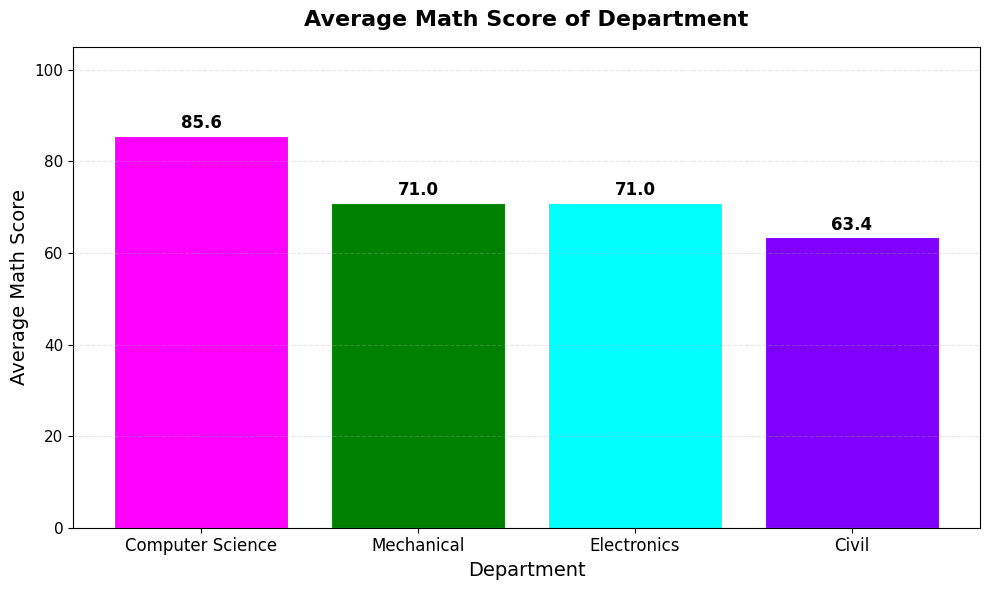

In [70]:
#get data using sql
chart1_sql="""
SELECT department,
ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=['#FF00FF','#008000','#00FFFF','#7F00FF']
bars=ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)
for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f"{height:.1f}",
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='black'
  )


ax.set_title("Average Math Score of Department",fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel("Department",fontsize=14)
ax.set_ylabel("Average Math Score",fontsize=14)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=12)
ax.tick_params(axis='y',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()


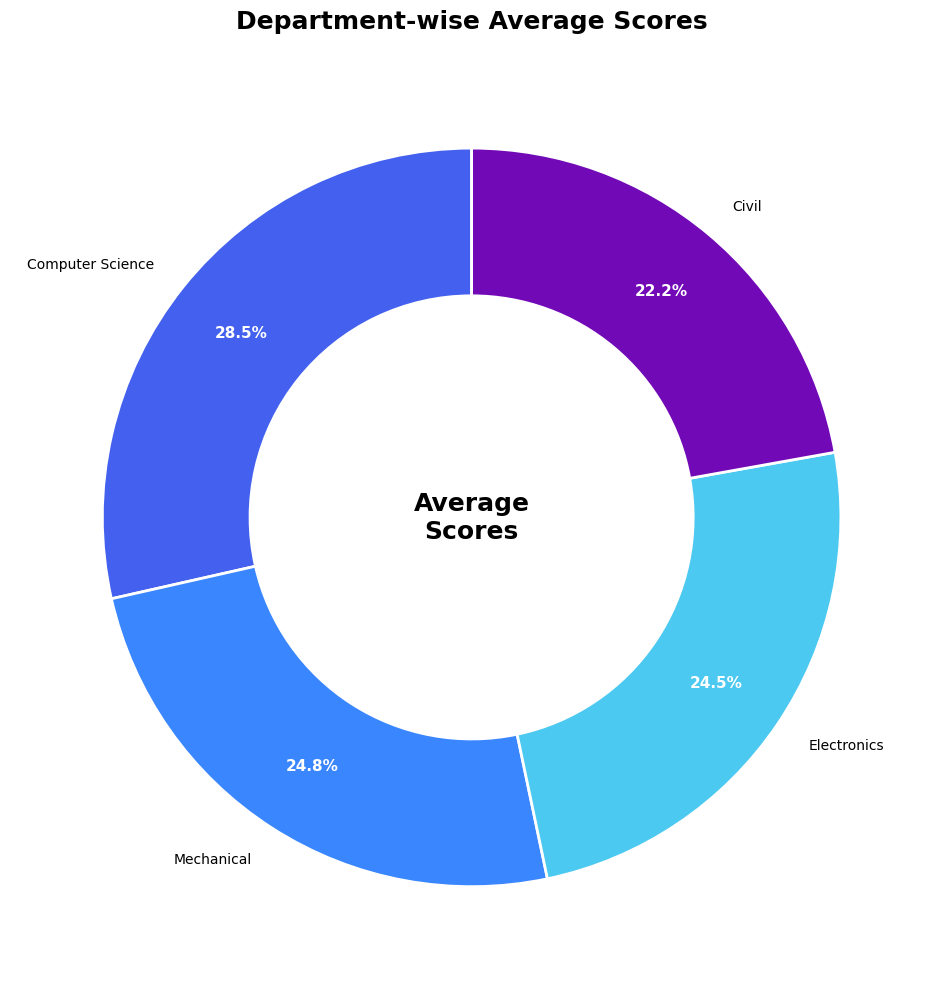

In [71]:
sql = """
SELECT department,
       ROUND(AVG((math_score + science_score + english_score)/3),2) AS avg_score
FROM students
GROUP BY department
ORDER BY avg_score DESC
"""
data = pd.read_sql_query(sql, conn)
colors = ['#4361EE', '#3A86FF', '#4CC9F0', '#7209B7', '#F72585']
fig, ax = plt.subplots(figsize=(10,10))
wedges, texts, autotexts = ax.pie(
    data['avg_score'],
    labels=data['department'],
    colors=colors[:len(data)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax.text(
    0, 0,
    "Average\nScores",
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)
ax.set_title(
    "Department-wise Average Scores",
    fontsize=18,
    fontweight='bold',
    pad=20
)
plt.tight_layout()
plt.show()

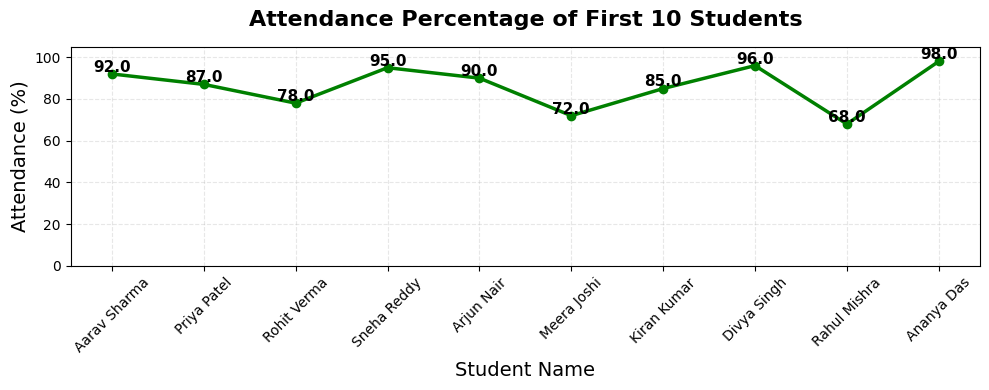

In [72]:
#get data using sql
chart3_sql="""
SELECT name, attendance_percentage
FROM students
LIMIT 10
"""

chart3_data=pd.read_sql_query(chart3_sql,conn)

fig,ax=plt.subplots(figsize=(10,4))

ax.plot(
    chart3_data['name'],
    chart3_data['attendance_percentage'],
    marker='o',
    linewidth=2.5,
    color='green'
)

for x,y in zip(chart3_data['name'],
               chart3_data['attendance_percentage']):
    ax.text(
        x,
        y+1,
        f"{y:.1f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title(
    "Attendance Percentage of First 10 Students",
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel("Student Name",fontsize=14)
ax.set_ylabel("Attendance (%)",fontsize=14)

ax.set_ylim(0,105)

ax.tick_params(axis='x',rotation=45)
ax.grid(alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()

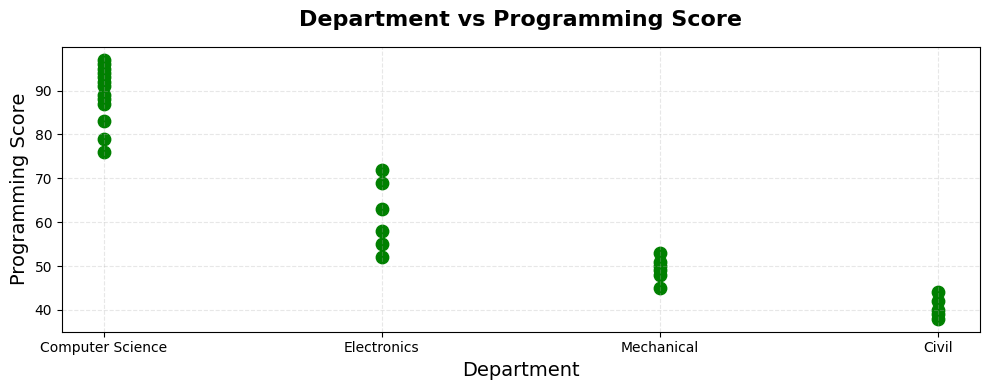

In [73]:
#get data using sql
chart4_sql="""
SELECT department, programming_score
FROM students
"""

chart4_data=pd.read_sql_query(chart4_sql,conn)

fig,ax=plt.subplots(figsize=(10,4))

ax.scatter(
    chart4_data['department'],
    chart4_data['programming_score'],
    color='green',
    s=80
)

ax.set_title(
    "Department vs Programming Score",
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel("Department",fontsize=14)
ax.set_ylabel("Programming Score",fontsize=14)

ax.grid(alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()

In [74]:
df_ml = df.copy()

le_gender = LabelEncoder()
df_ml['gender_encoded'] = le_gender.fit_transform(df_ml['gender'])

print("Gender Encoding:")
print(dict(zip(le_gender.classes_,
               le_gender.transform(le_gender.classes_))))

# Features and Target
X = df_ml[['gender_encoded']]
y = df_ml['math_score']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

print("\nModel Parameters")
print(f"Coefficient: {lr_model.coef_[0]:.3f}")
print(f"Bias (Intercept): {lr_model.intercept_:.3f}")

Gender Encoding:
{'Female': np.int64(0), 'Male': np.int64(1)}

Linear Regression
MAE: 11.85
RMSE: 13.22
R²: 0.0416

Model Parameters
Coefficient: -2.300
Bias (Intercept): 76.800
